# Tyre Equations Fitting

#### Summary

The following notebook has been provided to make it easier for customers to fit their existing tyre behaviour to the Canopy loaded and rolling radius equations, and rolling resistance model.

Following the instructions and running this notebook will produce saved configs which can be imported into your setups on the platform to produce very similar results to existing tyre fits. Be aware that you will need to manually load these configs in the car editor.
Note also that unless you are loading data from a `study_id`, the value of `rUnloaded` is also a fitted parameter, but it is not exported to the saved config. You should make sure that this matches your data, or adjust the script to fix `R0` when performing the fitting.

#### Contents

There are four steps to running this notebook:
1. Load the data you want to fit
2. Condition and check the data, to ensure it is in the right format for fitting and plotting
3. Fit the tyre equations to the data
4. Export saved configs using the fitted results


#### Using the Results

This notebook will generate saved configurations for the front and rear radius equations and rolling resistance sections. These can be imported using the "load config" button. The configuration will appear in the list and can be selected here, at which point it will overwrite your existing tyre loaded radius equations:

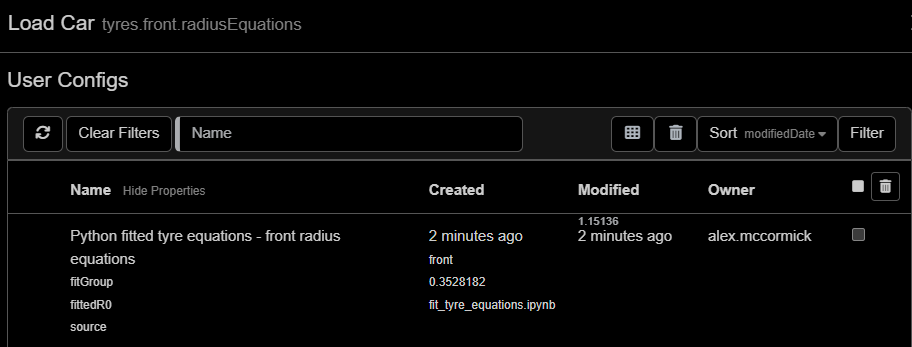


#### Prerequisites

API credentials are required. If these are unknown, contact Canopy and we can provide them.
The `canopy` python module is used. It should be downloaded automatically on running the notebook. If not, run the following code to ensure that the necessary requirements are installed.
```sh
python -m venv .venv
source ./.venv/bin/activate
pip install -r requirements.txt
```

#### Notes/Disclaimer

Although every reasonable effort has been made to test and validate this script, Canopy does not warrant or guarantee its accuracy or robustness. Edge cases will certainly exist that we have not foreseen. Efforts have been made to ensure that fitting is reasonable, but note that fitting is a purely mathematical process so the resulting configs may not extrapolate well beyond the fitted data.

The text in this notebook is hand-written, as is the method and the input handling. However, the conditioning, plotting, and fitting code has made extensive use of LLMs for development. As usual, you should check the output carefully before relying on it.

## 1. Import the Data

The first step in fitting the Canopy equations is to import the data that you want to fit. We support three different mechanisms - pick _one_ of the following cells to run. The three methods are:

- Load from a `study_id` using the API
- Load from local telemetry (in the Canopy export format; or results downloaded as a csv from the platform)
- Load from a provided data table or data book

### 1.1 Load data from a study

Use this if you have existing studies which contain loaded radius data that you want to fit to.

In [14]:
import canopy

# Set the study and simulation to extract
study_id = "261d01fe79e148e498f893b4324aa6db"
sim_type = "DynamicLap"

# Authenticate against the Canopy portal
authentication_data = canopy.prompt_for_authentication()
session = canopy.Session(authentication_data)

authenticated = True

# Load study metadata and enforce size limit
study_metadata = await canopy.load_study(
    session=session,
    study_id=study_id,
    include_study_sim_types=True)
if study_metadata.simulation_count > 20:
    raise ValueError(
        f"Study '{study_id}' contains {study_metadata.simulation_count} simulations. "
        "Maximum supported in this notebook is 20."
    )

if sim_type not in study_metadata.sim_types:
    raise ValueError(
        f"Study '{study_id}' does not contain simulation type '{sim_type}'. "
        f"Available simulation types: {', '.join(study_metadata.sim_types)}."
    )

# Load vector metadata to identify the result channels available for this study.
first_job = await canopy.load_study_job(
    session=session,
    study_id=study_id,
    sim_type=sim_type,
    job_index=0,
    include_inputs=True,
    include_vector_metadata=True)
channel_names = first_job.vector_metadata.index

# Extract rUnloaded for the front and rear tyres for the first simulation. This is used in the tyre fitting.
car_config = first_job.inputs._data["car"]

if car_config is None:
    raise ValueError("Car config is not available on first_job.")

front_r_unloaded = float(car_config["tyres"]["front"]["rUnloaded"])
rear_r_unloaded = float(car_config["tyres"]["rear"]["rUnloaded"])

print(f"front_r_unloaded = {front_r_unloaded}")
print(f"rear_r_unloaded = {rear_r_unloaded}")

# Download results: one dataframe per simulation/job
study = await canopy.load_study(
    session=session,
    study_id=study_id,
    sim_type=sim_type,
    channel_names=channel_names)
simulation_dataframes = [job.vector_data for job in study.jobs]

data_mode = "study"

print(f"Downloaded {len(simulation_dataframes)} simulation result dataframe(s).")

front_r_unloaded = 0.3528182
rear_r_unloaded = 0.3528182
Downloaded 5 simulation result dataframe(s).


### 1.2 Load Data From Telemetry Files

Use this if you have downloaded telemetry data from simulations and you want to use the downloaded (or imported) telemetry. Note the required fields in this step.

You also need to specify `rUnloaded` for the front and rear tyres, because this will not be fitted by the fitting process but it is an important parameter for the model.

In [1]:
file_paths = [
    'C:/canopy/t/samples/Sim 1/DynamicLap_VectorResults_sRun.csv',
    'C:/canopy/t/samples/Sim 2/DynamicLap_VectorResults_sRun.csv',
    'C:/canopy/t/samples/Sim 3/DynamicLap_VectorResults_sRun.csv',
]

front_r_unloaded = 0.3528182
rear_r_unloaded = 0.3528182

import pandas as pd

simulation_dataframes = []
for file_path in file_paths:
    # Headers are on row 2 and row 3 should be skipped so data starts at row 4.
    dataframe = pd.read_csv(file_path, header=1, skiprows=[2])
    simulation_dataframes.append(dataframe)

data_mode = "file"
authenticated = False

print(f"Loaded {len(simulation_dataframes)} simulation result dataframe(s).")

Loaded 3 simulation result dataframe(s).


### 1.3 Provide a Datatable

If you have a table of `rLoaded` vs `Fz` and `rRolling` vs `Fz` data, you can provide this data here and we will interpret it to generate the best fit to Canopy data.

The format of this data should be a single `Fz` array with the values of `rRolling` and `rLoaded` at the given `Fz` domain. `My` is based on the delta between `rRolling` and `rLoaded` so it will be fitted based on the difference between these values.

You also need to specify `rUnloaded` for the front and rear tyres, because this will not be fitted by the fitting process but it is an important parameter for the model.

In [4]:
import pandas as pd

# Enter values in SI units, Fz negative to match output signal convention
radius_fit = {
    "Fz": [-1000, -2000, -3000, -5000, -7000],
    "rLoaded": [0.3489, 0.3468, 0.3440, 0.3394, 0.3397],
    "rRolling": [0.3509, 0.3488, 0.3504, 0.3502, 0.3493],
    "MyRollingResistance": [2.5, 4.88, 7.66, 13.1, 17.6], # This is probably a function of rRolling - rLoaded, which means it can be fitted from this data
}


front_r_unloaded = 0.352
rear_r_unloaded = 0.352

data_mode = "table"
authenticated = False

# Accept either short names (Fz/rRolling/rLoaded) or full required names.
fz_values = radius_fit.get("FzTyre", radius_fit.get("Fz", []))
r_rolling_values = radius_fit.get("rTyreRollingRadius", radius_fit.get("rRolling", []))
r_loaded_values = radius_fit.get("rTyreLoaded", radius_fit.get("rLoaded", []))
my_values = radius_fit.get("MyRollingResistance", [])

lengths = [len(fz_values), len(r_rolling_values), len(r_loaded_values), len(my_values)]
if len(set(lengths)) != 1:
    raise ValueError(
        f"Input table lengths must match. Got lengths: "
        f"Fz={lengths[0]}, rRolling={lengths[1]}, rLoaded={lengths[2]}, My={lengths[3]}"
    )

row_count = lengths[0]

simulation_dataframes = [
    pd.DataFrame(
        {
            "FzTyre": fz_values,
            "MyRollingResistance": my_values,
            "rTyreLoaded": r_loaded_values,
            "rTyreRollingRadius": r_rolling_values,
            "nWheel": [0.0] * row_count,
            "pInflation": [0.0] * row_count,
            "aCamberTyre": [0.0] * row_count,
            "sRun": list(range(row_count)),
        }
    )
]

print(f"Created simulation_dataframes with {len(simulation_dataframes)} dataframe(s).")
print(simulation_dataframes[0].head())



Created simulation_dataframes with 1 dataframe(s).
   FzTyre  MyRollingResistance  rTyreLoaded  rTyreRollingRadius  nWheel  \
0   -1000                 2.50       0.3489              0.3509     0.0   
1   -2000                 4.88       0.3468              0.3488     0.0   
2   -3000                 7.66       0.3440              0.3504     0.0   
3   -5000                13.10       0.3394              0.3502     0.0   
4   -7000                17.60       0.3397              0.3493     0.0   

   pInflation  aCamberTyre  sRun  
0         0.0          0.0     0  
1         0.0          0.0     1  
2         0.0          0.0     2  
3         0.0          0.0     3  
4         0.0          0.0     4  


### Validate

We need to check that all the required columns exist. The key ones are (for each tyre XX:[FL|FR|RL|RR]):
- `FzTyreXX`
- `MyRollingResistanceXX`
- `rTyreLoadedXX`
- `rTyreRollingRadiusXX`
- `nWheelXX`

The following parameters are optional:
- `pInflationXX`
- `aCamberTyreXX`

In [2]:
import re
from pprint import pprint

REQUIRED_STATE_PARAMS = [
    "FzTyre",
    "MyRollingResistance",
    "rTyreLoaded",
    "rTyreRollingRadius",
    "nWheel",
]
OPTIONAL_STATE_PARAMS = [
    "pInflation",
    "aCamberTyre",
]
ALL_STATE_PARAMS = REQUIRED_STATE_PARAMS + OPTIONAL_STATE_PARAMS
TYRE_KEYS = ["FL", "FR", "RL", "RR", "unknown"]

# FzTyre needs to be inverted for the purposes of the fitting
COLUMN_SCALARS = {"FzTyre": -1.0}

def _canonicalise_column_name(column_name):
    # Strip sim-type suffixes and units so matching is stable for csv/api sources.
    name = str(column_name).strip()
    name = name.split(":", 1)[0]
    name = re.split(r"\s|\[", name, maxsplit=1)[0]
    return name


def _column_name_for_state(state_name, tyre_key):
    if tyre_key == "unknown":
        return state_name
    return f"{state_name}{tyre_key}"


if "simulation_dataframes" not in globals() or len(simulation_dataframes) == 0:
    raise ValueError(
        "simulation_dataframes is empty. Load study/csv data before running validation."
    )

# Use the intersection so we only mark states that exist in every dataframe.
common_columns = None
for index, dataframe in enumerate(simulation_dataframes):
    if dataframe is None or not hasattr(dataframe, "columns"):
        raise ValueError(
            f"simulation_dataframes[{index}] is not a valid pandas DataFrame."
        )

    canonical_columns = {_canonicalise_column_name(column) for column in dataframe.columns}
    if common_columns is None:
        common_columns = canonical_columns
    else:
        common_columns &= canonical_columns

if common_columns is None:
    raise ValueError("No columns found across simulation_dataframes.")

state_parameter_availability = {
    tyre_key: {
        state_name: _column_name_for_state(state_name, tyre_key) in common_columns
        for state_name in ALL_STATE_PARAMS
    }
    for tyre_key in TYRE_KEYS
}

tyres_with_data = [
    tyre_key
    for tyre_key, states in state_parameter_availability.items()
    if any(states.values())
]

if not tyres_with_data:
    raise ValueError(
        "No required/optional tyre state parameters were detected for "
        "FL/FR/RL/RR or unknown channels."
    )

missing_required_by_tyre = {}
for tyre_key in tyres_with_data:
    missing_required_states = [
        state_name
        for state_name in REQUIRED_STATE_PARAMS
        if not state_parameter_availability[tyre_key][state_name]
    ]
    if missing_required_states:
        missing_required_by_tyre[tyre_key] = [
            _column_name_for_state(state_name, tyre_key)
            for state_name in missing_required_states
        ]

if missing_required_by_tyre:
    message_lines = ["Required tyre state parameters are missing:"]
    for tyre_key, missing_columns in missing_required_by_tyre.items():
        message_lines.append(f"  - {tyre_key}: {', '.join(missing_columns)}")
    message_lines.append("These channels are required before fitting can continue.")
    raise ValueError("\n".join(message_lines))

for tyre_key in tyres_with_data:
    missing_optional_states = [
        state_name
        for state_name in OPTIONAL_STATE_PARAMS
        if not state_parameter_availability[tyre_key][state_name]
    ]
    if missing_optional_states:
        missing_optional_columns = [
            _column_name_for_state(state_name, tyre_key)
            for state_name in missing_optional_states
        ]
        print(
            f"{tyre_key}: optional parameter(s) missing: "
            f"{', '.join(missing_optional_columns)}. "
            "Terms related to these states will automatically be zeroed."
        )

if "unknown" in tyres_with_data:
    print(
        "unknown: unlabeled tyre channels detected. "
        "These will be treated as generic data for later processing."
    )

print("Tyres with detected data:", tyres_with_data)
pprint(state_parameter_availability)

Tyres with detected data: ['FL', 'FR', 'RL', 'RR']
{'FL': {'FzTyre': True,
        'MyRollingResistance': True,
        'aCamberTyre': True,
        'nWheel': True,
        'pInflation': True,
        'rTyreLoaded': True,
        'rTyreRollingRadius': True},
 'FR': {'FzTyre': True,
        'MyRollingResistance': True,
        'aCamberTyre': True,
        'nWheel': True,
        'pInflation': True,
        'rTyreLoaded': True,
        'rTyreRollingRadius': True},
 'RL': {'FzTyre': True,
        'MyRollingResistance': True,
        'aCamberTyre': True,
        'nWheel': True,
        'pInflation': True,
        'rTyreLoaded': True,
        'rTyreRollingRadius': True},
 'RR': {'FzTyre': True,
        'MyRollingResistance': True,
        'aCamberTyre': True,
        'nWheel': True,
        'pInflation': True,
        'rTyreLoaded': True,
        'rTyreRollingRadius': True},
 'unknown': {'FzTyre': False,
             'MyRollingResistance': False,
             'aCamberTyre': False,
         

## Fit the Equations

At this point, we have all of the necessary data to fit the equations. This means we need to start by defining the models.

Canopy's loaded radius model is defined as follows:

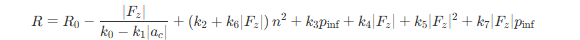


Canopy's rolling radius model is defined as follows:

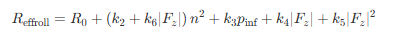


Finally, rolling resistance is a separate model with separate coefficients:

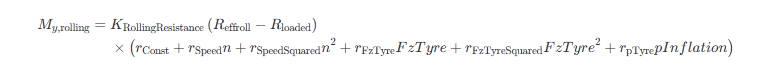

In [3]:
import numpy as np


def loaded_radius(R0, k, Fz, a_c, n, p_inf):
    """Return loaded radius from the Canopy tyre loaded-radius model.

    Parameters
    ----------
    R0 : float or array-like
        Unloaded tyre radius.
    k : array-like of length 8
        Model coefficients [k0, k1, k2, k3, k4, k5, k6, k7].
    Fz : float or array-like
        Vertical load state.
    a_c : float or array-like
        Tyre camber angle state.
    n : float or array-like
        Wheel speed state.
    p_inf : float or array-like
        Inflation pressure state.
    """
    k = np.asarray(k, dtype=float)
    if k.shape[0] != 8:
        raise ValueError("k must contain 8 coefficients: [k0, k1, k2, k3, k4, k5, k6, k7].")

    abs_Fz = np.abs(Fz)
    denom = k[0] - k[1] * np.square(a_c) / (np.sqrt(np.square(a_c) + 1e-6))
    if np.any(np.isclose(denom, 0.0)):
        raise ValueError("Invalid model state: k0 - k1*|a_c| must be non-zero.")

    return (
        R0
        - abs_Fz / denom
        + (k[2] + k[6] * abs_Fz) * np.square(n)
        + k[3] * p_inf
        + k[4] * abs_Fz
        + k[5] * np.square(abs_Fz)
        + k[7] * abs_Fz * p_inf
    )


def rolling_radius(R0, k, Fz, a_c, n, p_inf):
    """Return rolling radius from the Canopy tyre rolling-radius model.

    Parameters
    ----------
    R0 : float or array-like
        Unloaded tyre radius.
    k : array-like of length 8
        Model coefficients [k0, k1, k2, k3, k4, k5, k6, k7].
    Fz : float or array-like
        Vertical load state.
    a_c : float or array-like
        Tyre camber angle state.
    n : float or array-like
        Wheel speed state.
    p_inf : float or array-like
        Inflation pressure state.
    """
    k = np.asarray(k, dtype=float)
    if k.shape[0] != 8:
        raise ValueError("k must contain 8 coefficients: [k0, k1, k2, k3, k4, k5, k6, k7].")

    _ = a_c  # Included for signature consistency with loaded_radius.
    abs_Fz = np.abs(Fz)

    return (
        R0
        + (k[2] + k[6] * abs_Fz) * np.square(n)
        + k[3] * p_inf
        + k[4] * abs_Fz
        + k[5] * np.square(abs_Fz)
    )


def my_rolling_resistance(params, R_eff_roll, R_loaded, n, Fz_tyre, p_inflation):
    """Return MyRollingResistance from the rolling-resistance model.

    Parameters
    ----------
    params : dict
        Model parameters with keys:
        KRollingResistance, rConst, rSpeed, rSpeedSquared,
        rFzTyre, rFzTyreSquared, rTyrePInflation.
    R_eff_roll : float or array-like
        Effective rolling radius.
    R_loaded : float or array-like
        Loaded radius.
    n : float or array-like
        Wheel speed state.
    Fz_tyre : float or array-like
        Vertical load at tyre.
    p_inflation : float or array-like
        Inflation pressure state.
    """
    required_keys = [
        "KRollingResistance",
        "rConst",
        "rSpeed",
        "rSpeedSquared",
        "rFzTyre",
        "rFzTyreSquared",
        "rTyrePInflation",
    ]
    missing = [key for key in required_keys if key not in params]
    if missing:
        raise ValueError(f"Missing parameter(s): {missing}")

    return (
        params["KRollingResistance"]
        * (R_eff_roll - R_loaded)
        * (
            params["rConst"]
            + params["rSpeed"] * n
            + params["rSpeedSquared"] * np.square(n)
            + params["rFzTyre"] * Fz_tyre
            + params["rFzTyreSquared"] * np.square(Fz_tyre)
            + params["rTyrePInflation"] * p_inflation
        )
    )

### 2. Conditioning

We will condition the data into two dataframes, combining FL and FR data with "unknown", and RL and RR data with "unknown". This gives us two dictionaries with just the required and optional columns, one with data for "front" and one with data for "rear" tyres. These dictionaries will form the basis of the input data for fitting our coefficents to the models.

Front samples: 8178
Rear samples: 8178


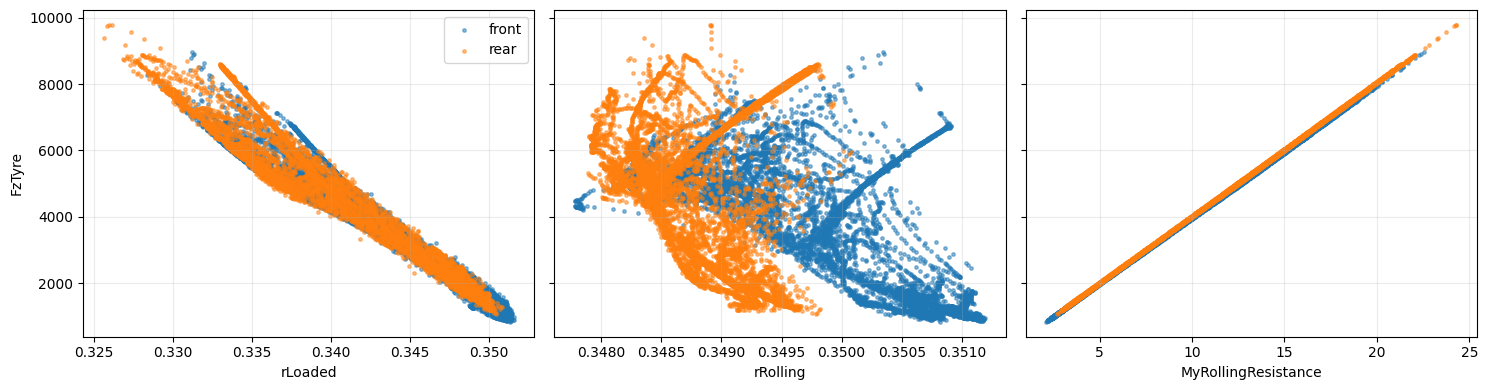

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Build front/rear conditioned datasets from the loaded simulation_dataframes.
# Each group is created by stacking tyre channels:
# - front: FL + FR + unknown
# - rear:  RL + RR + unknown
# Columns are normalised to state names without tyre suffixes.

GROUP_TYRE_KEYS = {
    "front": ["FL", "FR", "unknown"],
    "rear": ["RL", "RR", "unknown"],
}
PASSTHROUGH_COLUMNS = ["sRun"]


def _canonical_column_map(dataframe):
    """Map canonical column names -> source column names for one dataframe."""
    mapping = {}
    for column in dataframe.columns:
        canonical = _canonicalise_column_name(column)
        if canonical not in mapping:
            mapping[canonical] = column
    return mapping


def _build_group_dataframe(dataframes, tyre_keys):
    """Return a single conditioned dataframe for one tyre group."""
    chunks = []

    for dataframe in dataframes:
        canonical_map = _canonical_column_map(dataframe)

        for tyre_key in tyre_keys:
            required_canonical = [
                _column_name_for_state(state_name, tyre_key)
                for state_name in REQUIRED_STATE_PARAMS
            ]

            # Skip this tyre channel if any required state is missing in this dataframe.
            if not all(column in canonical_map for column in required_canonical):
                continue

            channel_df = pd.DataFrame({
                state_name: dataframe[canonical_map[_column_name_for_state(state_name, tyre_key)]].to_numpy()
                for state_name in REQUIRED_STATE_PARAMS
            })

            for state_name in OPTIONAL_STATE_PARAMS:
                canonical_name = _column_name_for_state(state_name, tyre_key)
                if canonical_name in canonical_map:
                    channel_df[state_name] = dataframe[canonical_map[canonical_name]].to_numpy()
                else:
                    # Optional terms are zeroed if not provided.
                    channel_df[state_name] = 0.0

            for state_name, state_scalar in COLUMN_SCALARS.items():
                if state_name in channel_df.columns:
                    channel_df[state_name] *= state_scalar

            for column_name in PASSTHROUGH_COLUMNS:
                if column_name in canonical_map:
                    channel_df[column_name] = dataframe[canonical_map[column_name]].to_numpy()

            channel_df["tyre_key"] = tyre_key
            chunks.append(channel_df)

    if not chunks:
        raise ValueError(f"No valid data found for tyre keys: {tyre_keys}")

    return pd.concat(chunks, ignore_index=True)


front_dataframe = _build_group_dataframe(simulation_dataframes, GROUP_TYRE_KEYS["front"])
rear_dataframe = _build_group_dataframe(simulation_dataframes, GROUP_TYRE_KEYS["rear"])

# Dictionaries for later fitting stages
front_data = {state_name: front_dataframe[state_name].to_numpy() for state_name in ALL_STATE_PARAMS}
rear_data = {state_name: rear_dataframe[state_name].to_numpy() for state_name in ALL_STATE_PARAMS}

print(f"Front samples: {len(front_dataframe)}")
print(f"Rear samples: {len(rear_dataframe)}")

# Validation plot: 1x3 scatter with x = rLoaded / rRolling / MyRollingResistance, y = FzTyre
plot_specs = [
    ("rTyreLoaded", "rLoaded"),
    ("rTyreRollingRadius", "rRolling"),
    ("MyRollingResistance", "MyRollingResistance"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (x_col, x_label) in zip(axes, plot_specs):
    ax.scatter(
        front_dataframe[x_col],
        front_dataframe["FzTyre"],
        s=6,
        alpha=0.5,
        color="tab:blue",
        label="front",
    )
    ax.scatter(
        rear_dataframe[x_col],
        rear_dataframe["FzTyre"],
        s=6,
        alpha=0.5,
        color="tab:orange",
        label="rear",
    )
    ax.set_xlabel(x_label)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("FzTyre")
axes[0].legend(loc="best")
fig.tight_layout()
plt.show()

### 3. Fitting

Now we need to fit our models to the data. This uses a `scipy` `least_squares` fit, which is perfectly adequate for the number of parameters we have to fit and gives good results if there is a lot of rich data.

It can take up to five minutes to run depending on the amount of data being used.

In [6]:
from pprint import pprint

from scipy.optimize import least_squares

RADIUS_PARAMETER_NAMES = [f"k{index}" for index in range(8)]
ROLLING_RESISTANCE_PARAMETER_NAMES = [
    "KRollingResistance",
    "rConst",
    "rSpeed",
    "rSpeedSquared",
    "rFzTyre",
    "rFzTyreSquared",
    "rTyrePInflation",
]
FIT_PARAMETER_NAMES = RADIUS_PARAMETER_NAMES + ROLLING_RESISTANCE_PARAMETER_NAMES
FIT_COLUMNS = [
    "FzTyre",
    "MyRollingResistance",
    "rTyreLoaded",
    "rTyreRollingRadius",
    "nWheel",
    "pInflation",
    "aCamberTyre",
]


def _finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]


def _magnitude(values, fallback=1.0):
    finite_values = np.abs(_finite_values(values))
    if finite_values.size == 0:
        return float(fallback)

    magnitude = np.nanpercentile(finite_values, 95)
    if not np.isfinite(magnitude) or magnitude <= 0.0:
        return float(fallback)
    return float(magnitude)


def _residual_scale(values):
    finite_values = _finite_values(values)
    if finite_values.size == 0:
        return 1.0

    spread = np.nanpercentile(finite_values, 95) - np.nanpercentile(finite_values, 5)
    if np.isfinite(spread) and spread > 0.0:
        return float(spread)

    return _magnitude(finite_values, fallback=1.0)


def _make_parameter_spec(initial, minimum, maximum, scale):
    initial = float(initial)
    minimum = float(minimum)
    maximum = float(maximum)
    scale = abs(float(scale))

    if not np.isfinite(scale) or scale <= 0.0:
        scale = max(abs(initial), 1.0)

    if minimum >= maximum:
        raise ValueError(f"Invalid parameter bounds: min={minimum}, max={maximum}")

    return {
        "initial": float(np.clip(initial, minimum, maximum)),
        "min": minimum,
        "max": maximum,
        "scale": scale,
    }


def _prepare_fit_dataframe(dataframe, name):
    missing_columns = [column for column in FIT_COLUMNS if column not in dataframe.columns]
    if missing_columns:
        raise ValueError(f"{name} dataframe is missing column(s): {missing_columns}")

    prepared = dataframe[FIT_COLUMNS].copy()
    prepared["pInflation"] = prepared["pInflation"].fillna(0.0)
    prepared["aCamberTyre"] = prepared["aCamberTyre"].fillna(0.0)

    finite_mask = np.isfinite(prepared.to_numpy(dtype=float)).all(axis=1)
    prepared = prepared.loc[finite_mask].reset_index(drop=True)

    if prepared.empty:
        raise ValueError(f"{name} dataframe does not contain any finite fit rows.")

    return prepared


def generate_initial_fit_parameter_specs(dataframe, r_unloaded):
    prepared = _prepare_fit_dataframe(dataframe, "initial guess")

    loaded_values = prepared["rTyreLoaded"].to_numpy(dtype=float)
    rolling_values = prepared["rTyreRollingRadius"].to_numpy(dtype=float)
    rolling_resistance_values = prepared["MyRollingResistance"].to_numpy(dtype=float)
    Fz_values = prepared["FzTyre"].to_numpy(dtype=float)
    n_values = prepared["nWheel"].to_numpy(dtype=float)
    p_inflation_values = prepared["pInflation"].to_numpy(dtype=float)
    a_camber_values = prepared["aCamberTyre"].to_numpy(dtype=float)

    radius_values = np.concatenate([loaded_values, rolling_values])
    radius_scale = _residual_scale(radius_values)
    radius_minimum = float(np.nanmin(radius_values))
    radius_maximum = float(np.nanmax(radius_values))

    abs_Fz_values = np.abs(Fz_values)
    Fz_scale = _magnitude(abs_Fz_values)
    n_scale = _magnitude(n_values)
    p_inflation_scale = _magnitude(p_inflation_values)
    a_camber_scale = _magnitude(a_camber_values)

    deflection = r_unloaded - loaded_values
    valid_stiffness_mask = (np.abs(deflection) > 1e-12) & (abs_Fz_values > 0.0)
    stiffness_samples = abs_Fz_values[valid_stiffness_mask] / deflection[valid_stiffness_mask]
    stiffness_samples = stiffness_samples[np.isfinite(stiffness_samples) & (stiffness_samples > 0.0)]
    k0_initial = float(np.nanmedian(stiffness_samples)) if stiffness_samples.size else Fz_scale / radius_scale
    k0_scale = max(abs(k0_initial), Fz_scale / radius_scale, 1.0)

    coefficient_scales = {
        "k0": k0_scale,
        "k1": k0_scale / a_camber_scale,
        "k2": radius_scale / np.square(n_scale),
        "k3": radius_scale / p_inflation_scale,
        "k4": radius_scale / Fz_scale,
        "k5": radius_scale / np.square(Fz_scale),
        "k6": radius_scale / (Fz_scale * np.square(n_scale)),
        "k7": radius_scale / (Fz_scale * p_inflation_scale),
    }

    radius_delta = rolling_values - loaded_values
    radius_delta_scale = _magnitude(radius_delta, fallback=radius_scale)
    rolling_resistance_scale = _magnitude(rolling_resistance_values)
    finite_delta_mask = np.abs(radius_delta) > 1e-12
    r_const_samples = rolling_resistance_values[finite_delta_mask] / radius_delta[finite_delta_mask]
    r_const_samples = r_const_samples[np.isfinite(r_const_samples)]
    r_const_initial = float(np.nanmedian(r_const_samples)) if r_const_samples.size else 0.0
    r_const_scale = max(abs(r_const_initial), rolling_resistance_scale / radius_delta_scale, 1.0)

    return {
        "k0": _make_parameter_spec(k0_initial, 1e-12, 1_000.0 * k0_scale, k0_scale),
        "k1": _make_parameter_spec(0.0, -1_000, 1_000.0, 100),
        "k2": _make_parameter_spec(0.0, -1_000.0 * coefficient_scales["k2"], 1_000.0 * coefficient_scales["k2"], coefficient_scales["k2"]),
        "k3": _make_parameter_spec(0.0, -1_000.0 * coefficient_scales["k3"], 1_000.0 * coefficient_scales["k3"], coefficient_scales["k3"]),
        "k4": _make_parameter_spec(0.0, -1_000.0 * coefficient_scales["k4"], 1_000.0 * coefficient_scales["k4"], coefficient_scales["k4"]),
        "k5": _make_parameter_spec(0.0, -1_000.0 * coefficient_scales["k5"], 1_000.0 * coefficient_scales["k5"], coefficient_scales["k5"]),
        "k6": _make_parameter_spec(0.0, -1_000.0 * coefficient_scales["k6"], 1_000.0 * coefficient_scales["k6"], coefficient_scales["k6"]),
        "k7": _make_parameter_spec(0.0, -1_000.0 * coefficient_scales["k7"], 1_000.0 * coefficient_scales["k7"], coefficient_scales["k7"]),
        "KRollingResistance": _make_parameter_spec(1.0, -1_000.0, 1_000.0, 1.0),
        "rConst": _make_parameter_spec(r_const_initial, -1_000.0 * r_const_scale, 1_000.0 * r_const_scale, r_const_scale),
        "rSpeed": _make_parameter_spec(0.0, -1_000.0 * r_const_scale / n_scale, 1_000.0 * r_const_scale / n_scale, r_const_scale / n_scale),
        "rSpeedSquared": _make_parameter_spec(0.0, -1_000.0 * r_const_scale / np.square(n_scale), 1_000.0 * r_const_scale / np.square(n_scale), r_const_scale / np.square(n_scale)),
        "rFzTyre": _make_parameter_spec(0.0, -1_000.0 * r_const_scale / Fz_scale, 1_000.0 * r_const_scale / Fz_scale, r_const_scale / Fz_scale),
        "rFzTyreSquared": _make_parameter_spec(0.0, -1_000.0 * r_const_scale / np.square(Fz_scale), 1_000.0 * r_const_scale / np.square(Fz_scale), r_const_scale / np.square(Fz_scale)),
        "rTyrePInflation": _make_parameter_spec(0.0, -1_000.0 * r_const_scale / p_inflation_scale, 1_000.0 * r_const_scale / p_inflation_scale, r_const_scale / p_inflation_scale),
    }


fit_parameter_specs = {
    "front": generate_initial_fit_parameter_specs(front_dataframe, front_r_unloaded),
    "rear": generate_initial_fit_parameter_specs(rear_dataframe, rear_r_unloaded),
}


def _scaled_fit_vectors(parameter_specs):
    initial_values = []
    lower_bounds = []
    upper_bounds = []

    for parameter_name in FIT_PARAMETER_NAMES:
        spec = parameter_specs[parameter_name]
        scale = spec["scale"]
        initial_values.append(spec["initial"] / scale)
        lower_bounds.append(spec["min"] / scale)
        upper_bounds.append(spec["max"] / scale)

    return (
        np.asarray(initial_values, dtype=float),
        np.asarray(lower_bounds, dtype=float),
        np.asarray(upper_bounds, dtype=float),
    )


def _unpack_scaled_parameters(scaled_parameter_values, parameter_specs):
    parameter_values = {}
    for parameter_name, scaled_value in zip(FIT_PARAMETER_NAMES, scaled_parameter_values):
        parameter_values[parameter_name] = float(scaled_value * parameter_specs[parameter_name]["scale"])

    k = np.asarray([parameter_values[f"k{index}"] for index in range(8)], dtype=float)
    params = {
        parameter_name: parameter_values[parameter_name]
        for parameter_name in ROLLING_RESISTANCE_PARAMETER_NAMES
    }

    return k, params


def _fit_tyre_group(group_name, dataframe, parameter_specs, r_unloaded):
    prepared = _prepare_fit_dataframe(dataframe, group_name)

    Fz_values = prepared["FzTyre"].to_numpy(dtype=float)
    loaded_target = prepared["rTyreLoaded"].to_numpy(dtype=float)
    rolling_target = prepared["rTyreRollingRadius"].to_numpy(dtype=float)
    rolling_resistance_target = prepared["MyRollingResistance"].to_numpy(dtype=float)
    n_values = prepared["nWheel"].to_numpy(dtype=float)
    p_inflation_values = prepared["pInflation"].to_numpy(dtype=float)
    a_camber_values = prepared["aCamberTyre"].to_numpy(dtype=float)

    loaded_scale = _residual_scale(loaded_target)
    rolling_scale = _residual_scale(rolling_target)
    rolling_resistance_scale = _residual_scale(rolling_resistance_target)

    def residuals(scaled_parameter_values):
        try:
            k, params = _unpack_scaled_parameters(scaled_parameter_values, parameter_specs)
            loaded_prediction = loaded_radius(
                r_unloaded,
                k,
                Fz_values,
                a_camber_values,
                n_values,
                p_inflation_values,
            )
            rolling_prediction = rolling_radius(
                r_unloaded,
                k,
                Fz_values,
                a_camber_values,
                n_values,
                p_inflation_values,
            )
            rolling_resistance_prediction = my_rolling_resistance(
                params,
                rolling_prediction,
                loaded_prediction,
                n_values,
                Fz_values,
                p_inflation_values,
            )
        except (FloatingPointError, ValueError):
            return np.full(3 * len(prepared), 1e9)

        residual_values = np.concatenate([
            (loaded_prediction - loaded_target) / loaded_scale,
            (rolling_prediction - rolling_target) / rolling_scale,
            (rolling_resistance_prediction - rolling_resistance_target) / rolling_resistance_scale,
        ])

        if not np.isfinite(residual_values).all():
            return np.full(3 * len(prepared), 1e9)

        return residual_values

    initial_values, lower_bounds, upper_bounds = _scaled_fit_vectors(parameter_specs)
    result = least_squares(
        residuals,
        initial_values,
        bounds=(lower_bounds, upper_bounds),
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=20_000,
        x_scale=1.0,
    )

    k, params = _unpack_scaled_parameters(result.x, parameter_specs)

    return {
        "result": result,
        "k": k,
        "params": params,
        "sample_count": len(prepared),
    }


fit_results = {
    "front": _fit_tyre_group("front", front_dataframe, fit_parameter_specs["front"], front_r_unloaded),
    "rear": _fit_tyre_group("rear", rear_dataframe, fit_parameter_specs["rear"], rear_r_unloaded),
}

for group_name, fit_result in fit_results.items():
    optimiser_result = fit_result["result"]
    print(f"\n{group_name.title()} fit")
    print(f"Samples: {fit_result['sample_count']}")
    print(f"Success: {optimiser_result.success}")
    print(f"Message: {optimiser_result.message}")
    print(f"Cost: {optimiser_result.cost}")
    print("k = [")
    for index, value in enumerate(fit_result["k"]):
        print(f"    {value},  # k{index}")
    print("]")
    print("params =")
    pprint(fit_result["params"])

front_fit_parameters = {
    "k": fit_results["front"]["k"],
    "params": fit_results["front"]["params"],
}
rear_fit_parameters = {
    "k": fit_results["rear"]["k"],
    "params": fit_results["rear"]["params"],
}


Front fit
Samples: 8178
Success: True
Message: `ftol` termination condition is satisfied.
Cost: 61.22154469765974
k = [
    430868.1729312797,  # k0
    -29.132492891732912,  # k1
    1.715553557763154e-08,  # k2
    -7.182970351245431e-09,  # k3
    -7.914866597507146e-07,  # k4
    3.460734062495772e-11,  # k5
    5.808589898251221e-12,  # k6
    1.2471054869690907e-12,  # k7
]
params =
{'KRollingResistance': 0.9775497323777216,
 'rConst': 1268.3658806920457,
 'rFzTyre': 0.0001159512997208566,
 'rFzTyreSquared': -1.3504550695711757e-08,
 'rSpeed': -0.056475918413826716,
 'rSpeedSquared': 7.84741902044773e-06,
 'rTyrePInflation': -0.0001607765642119408}

Rear fit
Samples: 8178
Success: True
Message: `ftol` termination condition is satisfied.
Cost: 115.1824593480081
k = [
    448978.784104205,  # k0
    -14.180962483665985,  # k1
    -9.983829118351795e-09,  # k2
    -1.6624353807401517e-08,  # k3
    -3.425977031342487e-07,  # k4
    2.0497222864080166e-12,  # k5
    6.71992172640451

### 3.1 Plotting

Take the input data and re-calculate the output loaded radius, rolling radius, and My. We can plot this against the actual data in both scatter plot and sRun domain.

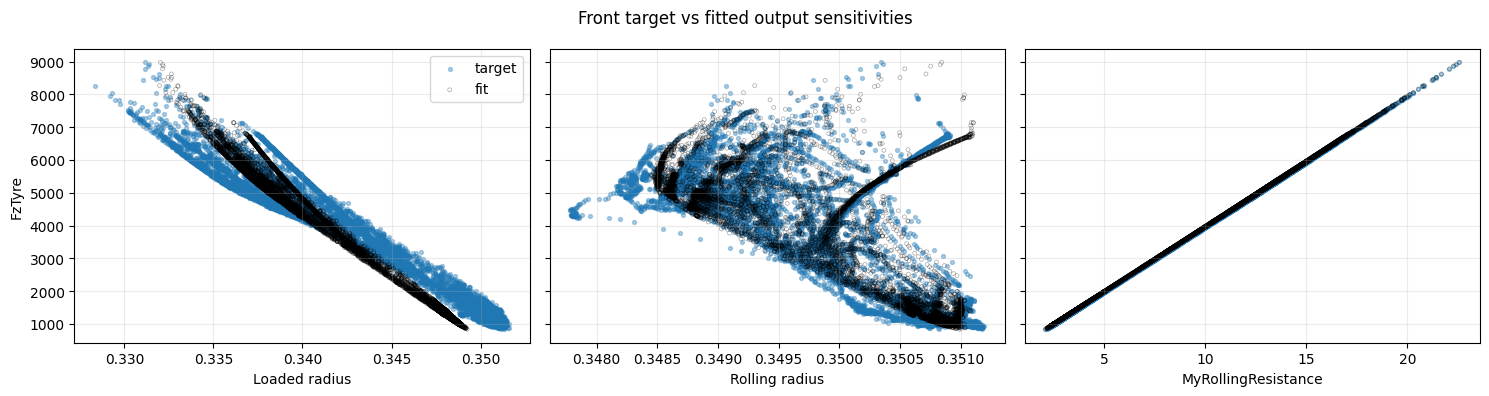

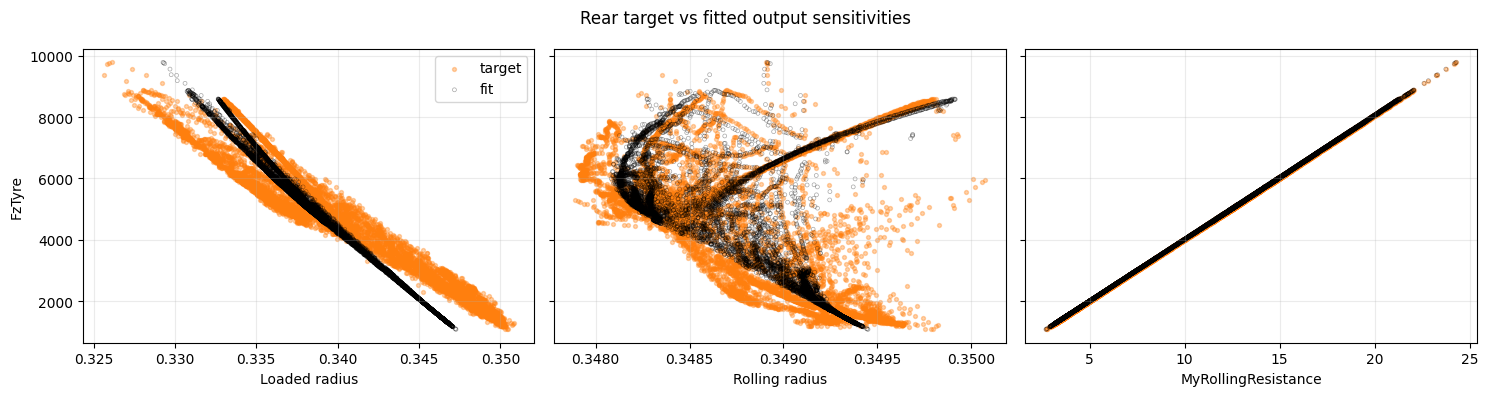

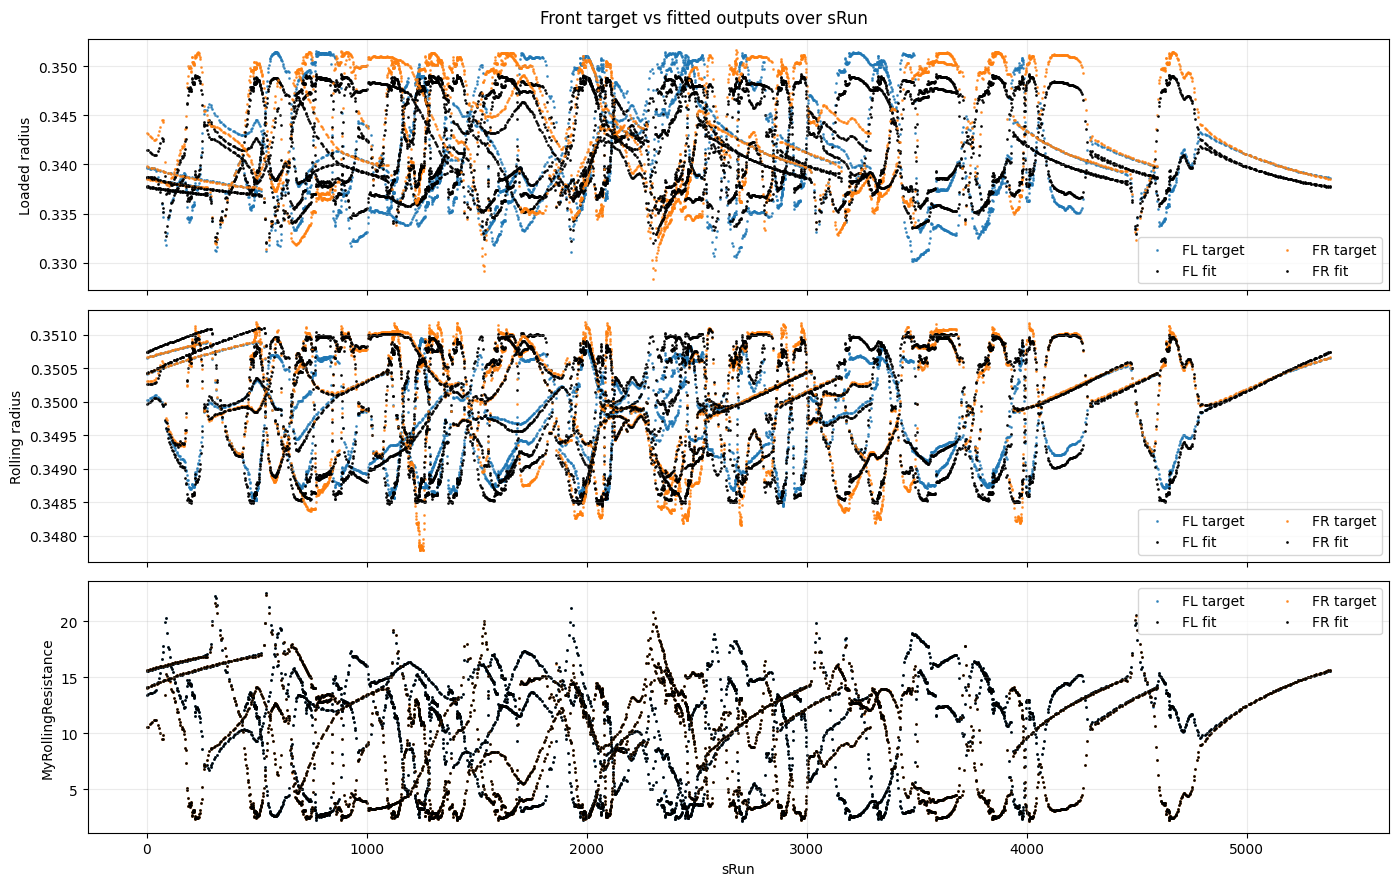

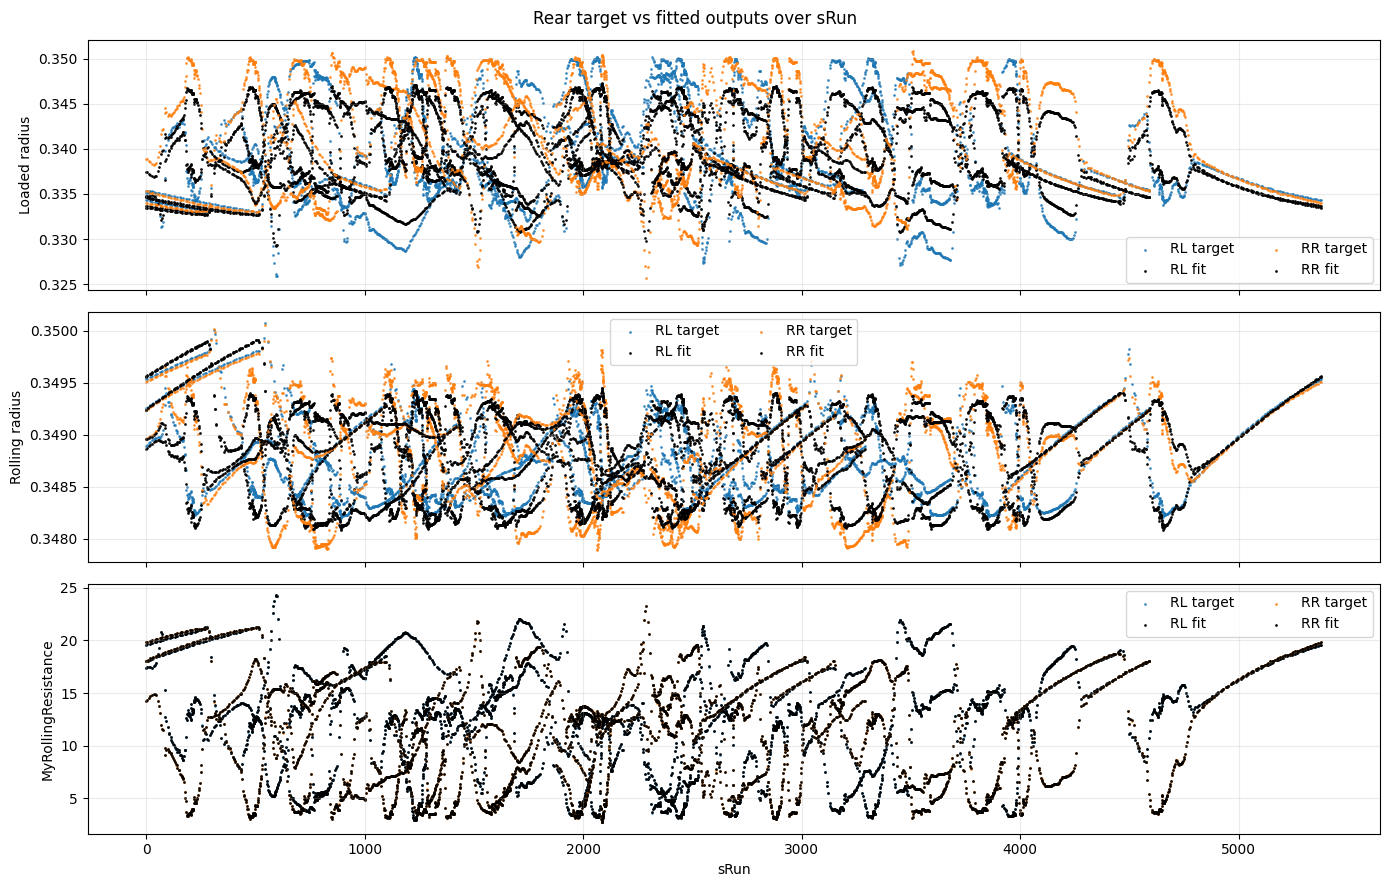

In [7]:
PREDICTED_COLUMN_SUFFIX = "Fit"
MODEL_OUTPUT_SPECS = [
    ("rTyreLoaded", "Loaded radius"),
    ("rTyreRollingRadius", "Rolling radius"),
    ("MyRollingResistance", "MyRollingResistance"),
]


if "front_fit_parameters" not in globals() or "rear_fit_parameters" not in globals():
    raise ValueError("Run the fitting cell before plotting fitted model outputs.")

if "sRun" not in front_dataframe.columns or "sRun" not in rear_dataframe.columns:
    raise ValueError(
        "sRun is not available in front_dataframe/rear_dataframe. "
        "Rerun the conditioning cell after loading data that contains sRun."
    )


def _add_model_predictions(dataframe, r_unloaded, fit_parameters):
    predicted = dataframe.copy()

    k = fit_parameters["k"]
    params = fit_parameters["params"]

    Fz_values = predicted["FzTyre"].to_numpy(dtype=float)
    n_values = predicted["nWheel"].to_numpy(dtype=float)
    p_inflation_values = predicted["pInflation"].to_numpy(dtype=float)
    a_camber_values = predicted["aCamberTyre"].to_numpy(dtype=float)

    loaded_prediction = loaded_radius(
        r_unloaded,
        k,
        Fz_values,
        a_camber_values,
        n_values,
        p_inflation_values,
    )
    rolling_prediction = rolling_radius(
        r_unloaded,
        k,
        Fz_values,
        a_camber_values,
        n_values,
        p_inflation_values,
    )
    rolling_resistance_prediction = my_rolling_resistance(
        params,
        rolling_prediction,
        loaded_prediction,
        n_values,
        Fz_values,
        p_inflation_values,
    )

    predicted[f"rTyreLoaded{PREDICTED_COLUMN_SUFFIX}"] = loaded_prediction
    predicted[f"rTyreRollingRadius{PREDICTED_COLUMN_SUFFIX}"] = rolling_prediction
    predicted[f"MyRollingResistance{PREDICTED_COLUMN_SUFFIX}"] = rolling_resistance_prediction

    return predicted


front_prediction_dataframe = _add_model_predictions(
    front_dataframe,
    front_r_unloaded,
    globals()["front_fit_parameters"],
)
rear_prediction_dataframe = _add_model_predictions(
    rear_dataframe,
    rear_r_unloaded,
    globals()["rear_fit_parameters"],
)

def _plot_scatter_comparison(group_name, dataframe, color):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, (target_column, label) in zip(axes, MODEL_OUTPUT_SPECS):
        fit_column = f"{target_column}{PREDICTED_COLUMN_SUFFIX}"
        ax.scatter(
            dataframe[target_column],
            dataframe["FzTyre"],
            s=8,
            alpha=0.35,
            color=color,
            label="target",
        )
        ax.scatter(
            dataframe[fit_column],
            dataframe["FzTyre"],
            s=8,
            alpha=0.35,
            facecolors="none",
            edgecolors="black",
            linewidths=0.5,
            label="fit",
        )
        ax.set_xlabel(label)
        ax.grid(True, alpha=0.25)

    axes[0].set_ylabel("FzTyre")
    axes[0].legend(loc="best")
    fig.suptitle(f"{group_name.title()} target vs fitted output sensitivities")
    fig.tight_layout()
    plt.show()


def _plot_srun_comparison(group_name, dataframe):
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    tyre_keys = [tyre_key for tyre_key in GROUP_TYRE_KEYS[group_name] if tyre_key in set(dataframe["tyre_key"])]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, (target_column, label) in zip(axes, MODEL_OUTPUT_SPECS):
        fit_column = f"{target_column}{PREDICTED_COLUMN_SUFFIX}"

        for index, tyre_key in enumerate(tyre_keys):
            tyre_dataframe = dataframe[dataframe["tyre_key"] == tyre_key].sort_values("sRun")
            color = colors[index % len(colors)]
            ax.scatter(
                tyre_dataframe["sRun"],
                tyre_dataframe[target_column],
                color=color,
                s=1,
                alpha=0.75,
                label=f"{tyre_key} target",
            )
            ax.scatter(
                tyre_dataframe["sRun"],
                tyre_dataframe[fit_column],
                color='black',
                s=1,
                alpha=0.9,
                label=f"{tyre_key} fit",
            )

        ax.set_ylabel(label)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", ncols=2)

    axes[-1].set_xlabel("sRun")
    fig.suptitle(f"{group_name.title()} target vs fitted outputs over sRun")
    fig.tight_layout()
    plt.show()


_plot_scatter_comparison("front", front_prediction_dataframe, "tab:blue")
_plot_scatter_comparison("rear", rear_prediction_dataframe, "tab:orange")

_plot_srun_comparison("front", front_prediction_dataframe)
_plot_srun_comparison("rear", rear_prediction_dataframe)

## Export to the Platform

Now that we have the fitted coefficients, we will export the components using the API so that they are available as saved configs.

In [ ]:
TYRE_CONFIG_EXPORT_NAME_PREFIX = "Python fitted tyre equations"
TYRE_RADIUS_CONFIG_NAME = "Canopy"
TYRE_ROLLING_RESISTANCE_CONFIG_NAME = "Canopy equation"

if not authenticated:
    import canopy
    authentication_data = canopy.prompt_for_authentication()
    session = canopy.Session(authentication_data)

    authenticated = True

session.authentication.authenticate()
sim_version = session.tenant_sim_version.get()

if "front_fit_parameters" not in globals() or "rear_fit_parameters" not in globals():
    raise ValueError("Run the fitting cell before exporting fitted tyre configs.")



def _json_float(value):
    value = float(value)
    if not np.isfinite(value):
        raise ValueError(f"Cannot export non-finite coefficient value: {value}")
    return value


def _json_float_list(values):
    return [_json_float(value) for value in values]


def _build_radius_equations_document(path, fit_parameters):
    return {
        "simVersion": sim_version,
        "path": path,
        "config": {
            "name": TYRE_RADIUS_CONFIG_NAME,
            "loadedRadius": {
                "krLoaded": _json_float_list(fit_parameters["k"]),
            },
        },
    }


def _build_rolling_resistance_document(path, fit_parameters):
    params = fit_parameters["params"]
    return {
        "simVersion": sim_version,
        "path": path,
        "config": {
            "name": TYRE_ROLLING_RESISTANCE_CONFIG_NAME,
            "kRollingResistance": _json_float(params["KRollingResistance"]),
            "rConst": _json_float(params["rConst"]),
            "rSpeed": _json_float(params["rSpeed"]),
            "rSpeedSquared": _json_float(params["rSpeedSquared"]),
            "rFzTyre": _json_float(params["rFzTyre"]),
            "rFzTyreSquared": _json_float(params["rFzTyreSquared"]),
            "rPTyre": _json_float(params["rTyrePInflation"]),
        },
    }


fitted_tyre_config_documents = {
    "front_radius_equations": _build_radius_equations_document(
        "tyres.front.radiusEquations",
        front_fit_parameters,
    ),
    "front_rolling_resistance": _build_rolling_resistance_document(
        "tyres.front.rollingResistance",
        front_fit_parameters,
    ),
    "rear_radius_equations": _build_radius_equations_document(
        "tyres.rear.radiusEquations",
        rear_fit_parameters,
    ),
    "rear_rolling_resistance": _build_rolling_resistance_document(
        "tyres.rear.rollingResistance",
        rear_fit_parameters,
    ),
}

created_tyre_config_ids = {}

for config_key, config_document in fitted_tyre_config_documents.items():
    saved_config_name = f"{TYRE_CONFIG_EXPORT_NAME_PREFIX} - {config_key.replace('_', ' ')}"
    # created_tyre_config_ids[config_key] = await canopy.create_config(
    #     session=session,
    #     config_type="car",
    #     name=saved_config_name,
    #     config_data=config_document["config"],
    #     sim_version=config_document["simVersion"],
    #     sub_tree_path=config_document["path"],
    #     properties={
    #         "source": "fit_tyre_equations.ipynb",
    #         "fitGroup": "front" if config_key.startswith("front") else "rear",
    #         "fittedR0": str(_json_float(
    #             front_r_unloaded if config_key.startswith("front") else rear_r_unloaded
    #         )),
    #     },
    #     notes=(
    #         "Generated from fitted tyre loaded-radius, rolling-radius, "
    #         "and rolling-resistance coefficients in fit_tyre_equations.ipynb."
    #     ),
    # )

print(f"Exported fitted tyre configs for sim version {sim_version}:")
for config_key, config_id in created_tyre_config_ids.items():
    print(f"{config_key}: {config_id}")

RuntimeError: You must call authenticate before requesting tenant ID.